# NB02 — Diagnostic: is TTR variability process noise, or does it have structure?

## 1. The question

Every provider status page eventually says some version of the same reassuring thing: incidents resolve in about an hour. That sentence is usually true, and it is also close to useless for planning, because "about an hour" almost always names the median, and almost no operational decision runs on the median. When a status page reports a typical resolution time, which number should actually go into a staffing model, a runbook, or an escalation clock: the mean, the median, or a high percentile?

## 2. Three decisions, three different numbers

A support/NOC lead who depends on third-party cloud services has to turn "how long do provider incidents last?" into three different operational numbers, and mixing them up is not a rounding error: it means feeding the wrong number into the wrong decision. Capacity planning runs on the mean, not the median: Little's law and every queueing formula consume the mean service time and its variability, and if the squared coefficient of variation of service time (c²ₛ) sits far above 1, a staffing plan built on the mean alone will still underestimate waiting, since that variability is the V factor in the VUT equation and is the direct input to NB03. Communicating a "typical" incident to users or in a runbook is a job for the median, the honest answer to "what usually happens." And promises or escalation triggers (SLOs, "when do we declare a crisis?") need a high percentile, because in a right-skewed distribution a meaningful minority of incidents runs several times the median.

If TTR were roughly symmetric, these three numbers would nearly coincide and the question above would be boring. This notebook tests whether it is — and, if not, characterizes how skewed it is, whether the skew has a recognizable distributional shape (log-normal, as maintenance theory predicts), and what the mean/median gap and c²ₛ are per provider.

## 3. The data and its limits

**Source:** `data/real/service_incidents.csv`, 787 incidents scraped from the public status pages of 18 cloud providers (captured 2026-06-27, expanded 2026-07-03). Real observational data; nothing was generated or planted.

Known limits, declared up front:

1. Status-page censorship. Providers only publish incidents *they chose to declare*. Durations measure declare→resolve on the status page, i.e. detect + mitigate + communicate, not pure repair time. This matters for the theory test below.
2. Per-provider observation windows differ wildly. Each status-page API returns roughly the last ~50 incidents, which covers ≈8 days for Twilio and ≈6 years for Atlassian. Cross-provider *duration* comparisons are fine (each incident's duration is self-contained); cross-provider *rate* comparisons are not made in this notebook at all, since they require per-window normalization (NB01's job).
3. Twilio caveat. Twilio's 50 incidents span ~8 days, very likely one correlated platform crisis rather than 50 independent draws. A with/without-Twilio sensitivity analysis is run on every headline result (§4.8).
4. Impact conventions are not comparable across providers. Figma and Atlassian label almost everything `none`; Discord uses `major` liberally. Impact is therefore analyzed within the pooled set only as *strata*, with this caveat attached, never as a calibrated cross-provider severity scale.
5. Exclusions. GCP (3 incidents, none with a resolution time) is excluded from all duration analysis. Incidents without a `resolved_at`, and incidents with recorded duration ≤ 0 minutes (status-page bookkeeping artifacts: created and resolved stamped at the same second, or resolved before created), are excluded and counted below.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(20240401)

# --- palette (validated categorical/ink tokens) ---
BLUE, AQUA, YELLOW, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": INK2,
    "ytick.color": INK2, "text.color": INK, "font.size": 10,
    "axes.titlesize": 11, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
})

df = pd.read_csv("data/real/service_incidents.csv")
df["created_at"] = pd.to_datetime(df["created_at"], format="ISO8601", utc=True)

n_total = len(df)
n_no_duration = df["duration_min"].isna().sum()
n_nonpos = (df["duration_min"] <= 0).sum()
ttr = df[df["duration_min"] > 0].copy()
ttr["log_ttr"] = np.log(ttr["duration_min"])

print(f"Total incidents: {n_total} from {df['provider'].nunique()} providers")
print(f"Excluded — no resolved_at/duration: {n_no_duration} (includes all 3 GCP incidents)")
print(f"Excluded — duration <= 0 min (bookkeeping artifacts): {n_nonpos}")
print(f"Analyzable TTR sample: {len(ttr)} incidents, {ttr['provider'].nunique()} providers")

# per-provider observation window + counts
win = df.groupby("provider")["created_at"].agg(["min", "max"])
win["window_days"] = (win["max"] - win["min"]).dt.total_seconds() / 86400
counts = ttr.groupby("provider")["duration_min"].agg(
    n_resolved="count", median_min="median", mean_min="mean")
overview = counts.join(win["window_days"]).sort_values("n_resolved", ascending=False).round(1)
overview

Total incidents: 787 from 18 providers
Excluded — no resolved_at/duration: 13 (includes all 3 GCP incidents)
Excluded — duration <= 0 min (bookkeeping artifacts): 53
Analyzable TTR sample: 721 incidents, 17 providers


,n_resolved,median_min,mean_min,window_days
provider,,,,
zoom,50,72.2,922.0,65.2
npm,50,101.4,174.0,990.6
datadog,50,84.7,170.0,303.4
reddit,50,66.6,263.9,755.2
claude_anthropic,48,58.9,84.4,30.0
discord,48,55.4,430.4,324.8
dropbox,45,146.3,1650.3,775.8
circleci,45,78.9,160.3,211.1
github,45,112.6,222.2,64.8


Every provider that survives the exclusions has **≥ 20 resolved incidents with positive duration**, so the pre-registered ≥ 20 threshold for per-provider fitting (declared below) excludes only GCP; there is no residual "other" pool to report beyond that. Note the `window_days` column: Twilio's ~8-day window versus Atlassian's ~6-year window is exactly why no per-provider *rates* appear anywhere in this notebook.


### 4.1 Pre-registration — decision rules declared *before* fitting anything

To keep my analysis honest here, the following choices are fixed beforehand, as a proposal for best practice:

1. Distribution contest. Four candidate families for `duration_min`, fit per provider by maximum likelihood with location fixed at 0 (durations are positive): log-normal, exponential, Weibull, gamma. Free parameters: 2, 1, 2, 2.
2. Model comparison rule: AIC. ΔAIC < 2 between the top models counts as statistically indistinguishable at this n — a tie is reported as a tie, not as a winner. Akaike weights are reported for all four families, not just the best one.
3. The prior can lose. Maintenance theory (Kline 1984) predicts log-normal repair times for multi-component systems. But a status page measures detect + mitigate + communicate, a different process, so the actual AIC winner is reported even if it contradicts the log-normal prior, and a contradiction would be a finding, not a failure.
4. Per-provider fitting threshold: providers with ≥ 20 resolved positive-duration incidents; the rest are pooled into an "other" note (per the data above: only GCP falls out).
5. Formal log-normality check: Shapiro-Wilk on ln(TTR) per provider, α = 0.05, plus normal QQ-plots of ln(TTR).
6. Outliers: generalized ESD (GESD) on ln(TTR) with r = 5 (maximum outliers to test, fixed now, not adjusted post hoc), α = 0.05. Because provider medians differ, GESD runs on provider-median-centered ln(TTR), otherwise a whole slow provider would masquerade as outliers. Flagged incidents are then read qualitatively: names, providers, what they had in common.
7. Severity strata: critical vs minor and major vs minor compared with Mann-Whitney U (no t-tests on skewed, small-n strata) plus a bootstrap 95% CI on the difference of medians (10,000 resamples), reporting CI width honestly.
8. Twilio sensitivity: every headline number (pooled median/mean, pooled c²ₛ, contest outcome, severity tests) recomputed without Twilio; changes reported.
9. Determinism: `np.random.default_rng(20240401)` for all resampling.

### 4.2 The shape of TTR — and the multiplicative-process story

First, just look at the pooled distribution, on a linear scale and on a log scale.


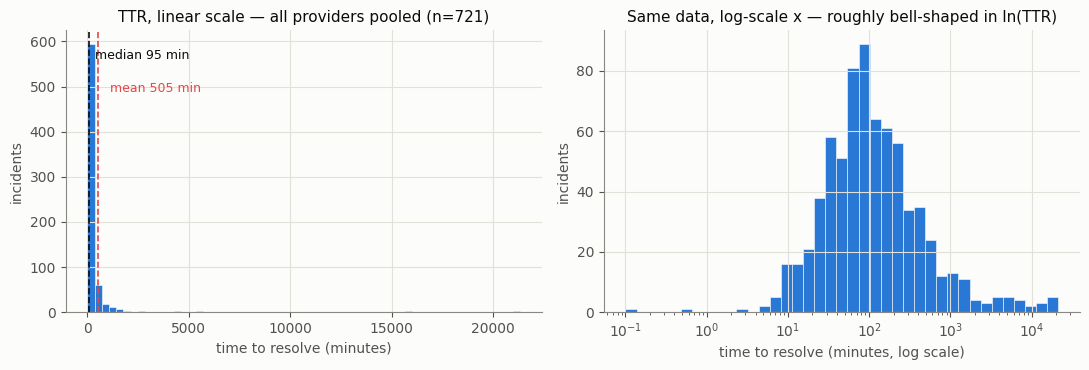

Pooled TTR: mean 505 min | median 95 min | mean/median ratio 5.3x
Percentiles (min): {'p50': 95.0, 'p75': 226.0, 'p90': 601.0, 'p95': 1391.0, 'p99': 11219.0}


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

x = ttr["duration_min"]
axes[0].hist(x, bins=60, color=BLUE, edgecolor="#fcfcfb", linewidth=0.4)
axes[0].set_xlabel("time to resolve (minutes)")
axes[0].set_ylabel("incidents")
axes[0].set_title(f"TTR, linear scale — all providers pooled (n={len(x)})")
axes[0].axvline(x.median(), color=INK, lw=1.2, ls="--")
axes[0].axvline(x.mean(), color=RED, lw=1.2, ls="--")
axes[0].annotate(f"median {x.median():.0f} min", xy=(x.median(), axes[0].get_ylim()[1]*0.9),
                 xytext=(x.median()*4, axes[0].get_ylim()[1]*0.9), color=INK, fontsize=9)
axes[0].annotate(f"mean {x.mean():.0f} min", xy=(x.mean(), axes[0].get_ylim()[1]*0.78),
                 xytext=(x.mean()*2.2, axes[0].get_ylim()[1]*0.78), color=RED, fontsize=9)

bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)
axes[1].hist(x, bins=bins, color=BLUE, edgecolor="#fcfcfb", linewidth=0.4)
axes[1].set_xscale("log")
axes[1].set_xlabel("time to resolve (minutes, log scale)")
axes[1].set_ylabel("incidents")
axes[1].set_title("Same data, log-scale x — roughly bell-shaped in ln(TTR)")
fig.tight_layout()
plt.show()

q = x.quantile([0.5, 0.75, 0.9, 0.95, 0.99])
print(f"Pooled TTR: mean {x.mean():.0f} min | median {x.median():.0f} min "
      f"| mean/median ratio {x.mean()/x.median():.1f}x")
print("Percentiles (min):", {f"p{int(k*100)}": round(v, 0) for k, v in q.items()})

The linear-scale histogram is the whole argument in one picture: a huge spike of short incidents and a tail stretching to *days*. On a log-scale x-axis the same data looks roughly bell-shaped — the classic signature of a **multiplicative process**.

**Why multiplicative?** An incident's total duration is not a sum of independent delays; it is closer to a *product* of factors: how fast it was detected × how ambiguous the diagnosis was × how many teams had to coordinate × whether the fix was a config flip or a rollback or a data repair × how cautiously it was verified before "resolved" was posted. Multiply many positive random factors and the Central Limit Theorem acts on the *logs*: ln(TTR) tends to normal, i.e. TTR tends to **log-normal**. This is Kline's (1984) argument for repair times of multi-component systems, and it is the theoretical prior the pre-registered contest below is allowed to reject, because a status page timestamp measures detection-to-communication, not wrench-time.


### 4.3 Median vs mean per provider — two numbers, two decisions

The mean/median gap is not a nuisance; each number serves a different decision. The **median** answers "what does a typical incident look like?": use it for user communication and runbook expectations. The **mean** is what queueing/capacity math consumes (offered load = λ × *mean* service time), use it, with its variability, for staffing. Budgeting staff with the median, or setting user expectations with the mean, both systematically mislead — in opposite directions.


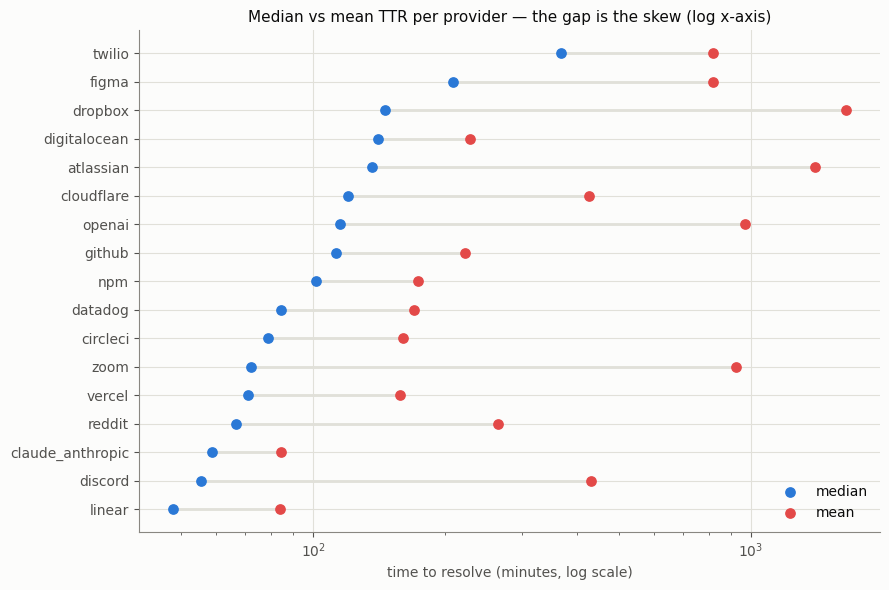

                   n  median    mean  mean_over_median
provider                                              
linear            22    47.8    84.2               1.8
discord           48    55.4   430.4               7.8
claude_anthropic  48    58.9    84.4               1.4
reddit            50    66.6   263.9               4.0
vercel            44    70.9   158.1               2.2
zoom              50    72.2   922.0              12.8
circleci          45    78.9   160.3               2.0
datadog           50    84.7   170.0               2.0
npm               50   101.4   174.0               1.7
github            45   112.6   222.2               2.0
openai            24   115.5   969.4               8.4
cloudflare        43   120.0   426.4               3.6
atlassian         30   136.3  1402.3              10.3
digitalocean      42   140.6   227.8               1.6
dropbox           45   146.3  1650.3              11.3
figma             43   208.5   817.5               3.9
twilio    

In [3]:
prov_stats = ttr.groupby("provider")["duration_min"].agg(
    n="count", median="median", mean="mean").sort_values("median")
prov_stats["mean_over_median"] = prov_stats["mean"] / prov_stats["median"]

fig, ax = plt.subplots(figsize=(9, 6))
ypos = np.arange(len(prov_stats))
for y, (prov, row) in zip(ypos, prov_stats.iterrows()):
    ax.plot([row["median"], row["mean"]], [y, y], color=GRID, lw=2, zorder=1)
ax.scatter(prov_stats["median"], ypos, color=BLUE, s=45, zorder=3, label="median")
ax.scatter(prov_stats["mean"], ypos, color=RED, s=45, zorder=3, label="mean")
ax.set_yticks(ypos, prov_stats.index)
ax.set_xscale("log")
ax.set_xlabel("time to resolve (minutes, log scale)")
ax.set_title("Median vs mean TTR per provider — the gap is the skew (log x-axis)")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

print(prov_stats.round(1).to_string())
print(f"\nMean/median ratio across providers: min {prov_stats['mean_over_median'].min():.1f}x, "
      f"median {prov_stats['mean_over_median'].median():.1f}x, "
      f"max {prov_stats['mean_over_median'].max():.1f}x")

**Every single provider has mean > median** — the skew is universal, only its magnitude varies. A provider quoting "we resolve in about an hour" is almost certainly quoting a median; the mean you must staff for is typically 1.5–11× larger depending on the provider. Note this is a *duration* comparison across providers, which the window caveat permits.


### 4.4 The pre-registered distribution contest

Four families, MLE with `loc=0`, per provider (all pass the ≥20 threshold), compared by AIC with the ΔAIC < 2 tie rule and Akaike weights (exactly as declared in §4.1).


In [4]:
FAMILIES = {
    "lognormal":   (stats.lognorm,     2),
    "exponential": (stats.expon,       1),
    "weibull":     (stats.weibull_min, 2),
    "gamma":       (stats.gamma,       2),
}

def fit_contest(x):
    """Fit all 4 families (loc fixed at 0), return dict of AIC and params."""
    out = {}
    for name, (dist, k) in FAMILIES.items():
        if name == "exponential":
            params = dist.fit(x, floc=0)
        else:
            params = dist.fit(x, floc=0)
        ll = dist.logpdf(x, *params).sum()
        out[name] = {"aic": 2 * k - 2 * ll, "params": params}
    return out

rows = []
fits_by_provider = {}
for prov, g in ttr.groupby("provider"):
    x = g["duration_min"].to_numpy()
    if len(x) < 20:
        continue
    res = fit_contest(x)
    fits_by_provider[prov] = res
    aics = {k: v["aic"] for k, v in res.items()}
    best = min(aics, key=aics.get)
    delta = {k: v - aics[best] for k, v in aics.items()}
    w = {k: np.exp(-0.5 * d) for k, d in delta.items()}
    tot = sum(w.values())
    w = {k: v / tot for k, v in w.items()}
    ties = sorted([k for k, d in delta.items() if d < 2])
    rows.append({"provider": prov, "n": len(x), "winner": best,
                 **{f"dAIC_{k}": round(delta[k], 1) for k in FAMILIES},
                 **{f"w_{k}": round(w[k], 2) for k in FAMILIES},
                 "indistinguishable(dAIC<2)": ", ".join(ties)})

contest = pd.DataFrame(rows).set_index("provider").sort_values("n", ascending=False)
print("Winner counts (raw AIC minimum):", contest["winner"].value_counts().to_dict())
sole = contest[contest["indistinguishable(dAIC<2)"].apply(lambda s: "," not in s)]
print(f"Providers where the winner is SOLE (no dAIC<2 tie): {len(sole)}/{len(contest)}"
      f" -> {dict(sole['winner'].value_counts())}")
lognorm_in_tie = contest["indistinguishable(dAIC<2)"].str.contains("lognormal").sum()
print(f"Providers where lognormal is in the dAIC<2 set: {lognorm_in_tie}/{len(contest)}")
contest[["n", "winner", "dAIC_lognormal", "dAIC_exponential", "dAIC_weibull", "dAIC_gamma",
         "w_lognormal", "w_exponential", "w_weibull", "w_gamma", "indistinguishable(dAIC<2)"]]

Winner counts (raw AIC minimum): {'lognormal': 16, 'weibull': 1}
Providers where the winner is SOLE (no dAIC<2 tie): 14/17 -> {'lognormal': np.int64(14)}
Providers where lognormal is in the dAIC<2 set: 17/17


,n,winner,dAIC_lognormal,dAIC_exponential,dAIC_weibull,dAIC_gamma,w_lognormal,w_exponential,w_weibull,w_gamma,indistinguishable(dAIC<2)
provider,,,,,,,,,,,
zoom,50,lognormal,0.0,107.9,20.2,37.6,1.00,0.00,0.00,0.00,lognormal
npm,50,lognormal,0.0,13.3,14.6,12.2,1.00,0.00,0.00,0.00,lognormal
datadog,50,lognormal,0.0,25.8,20.1,26.0,1.00,0.00,0.00,0.00,lognormal
reddit,50,lognormal,0.0,45.6,23.5,34.8,1.00,0.00,0.00,0.00,lognormal
claude_anthropic,48,lognormal,0.0,4.6,4.8,3.5,0.73,0.08,0.07,0.13,lognormal
discord,48,lognormal,0.0,90.1,19.5,40.9,1.00,0.00,0.00,0.00,lognormal
dropbox,45,lognormal,0.0,94.8,14.8,28.9,1.00,0.00,0.00,0.00,lognormal
circleci,45,lognormal,0.0,15.4,13.0,16.3,1.00,0.00,0.00,0.00,lognormal
github,45,lognormal,0.0,20.4,14.9,20.2,1.00,0.00,0.00,0.00,lognormal


The log-normal prior survived, and I'll admit I wanted it to — Kline's theory is elegant, and it would have been a shame to lose it. And yet the honest version is less clean than "log-normal wins": log-normal is the raw AIC minimum for 16 of 17 providers, and the sole winner (no competitor within ΔAIC < 2) for 14 of 17, with an Akaike weight of at least 0.94 in those 14. The other three are genuine ties, reported as ties per the pre-registered rule: figma (Weibull at ΔAIC = 1.1), linear (exponential at ΔAIC = 0.4, at n = 22 the data simply cannot tell a one-parameter memoryless model and log-normal apart), and twilio, the one provider where Weibull is the raw winner but log-normal sits at ΔAIC = 1.8, statistically indistinguishable. That sole Weibull win belongs, tellingly, to the one provider whose entire sample is an 8-day crisis window (§4.9). Across all seventeen, log-normal is inside the ΔAIC < 2 set every time: no provider's data rejects it relative to these alternatives. Exponential, meanwhile, loses decisively almost everywhere (ΔAIC 3.8–108, competitive only for linear), and that failure is itself operationally meaningful: the memoryless model does not hold, so an incident that has already run two hours really is evidence of a longer one, and time-based escalation clocks are statistically rational, not just cautious.

Two honesty notes belong here. AIC is a relative comparison among four candidates: it cannot certify that log-normal is true, only that it beats these rivals; §4.5 asks the absolute question. And per §4.1, this outcome was allowed to go the other way: it happens that the Kline-1984 prior held up even though status-page TTR measures detect-mitigate-communicate rather than pure repair.

### 4.5 Formal log-normality check — Shapiro-Wilk on ln(TTR) and QQ-plots

AIC says which of four candidates fits *least badly*; Shapiro-Wilk on ln(TTR) asks the absolute question: is ln(TTR) actually normal? At n≈50 per provider the test has decent power against gross violations.


In [5]:
sw_rows = []
for prov, g in ttr.groupby("provider"):
    lx = g["log_ttr"].to_numpy()
    if len(lx) < 20:
        continue
    W, p = stats.shapiro(lx)
    sw_rows.append({"provider": prov, "n": len(lx), "W": round(W, 3),
                    "p_value": round(p, 4), "reject_lognormality_(a=0.05)": p < 0.05})
sw = pd.DataFrame(sw_rows).set_index("provider").sort_values("p_value")
n_reject = sw["reject_lognormality_(a=0.05)"].sum()
print(f"Shapiro-Wilk on ln(TTR): log-normality rejected for {n_reject}/{len(sw)} providers at a=0.05")
sw

Shapiro-Wilk on ln(TTR): log-normality rejected for 8/17 providers at a=0.05


,n,W,p_value,reject_lognormality_(a=0.05)
provider,,,,
zoom,50,0.895,0.0003,True
figma,43,0.885,0.0004,True
reddit,50,0.914,0.0015,True
discord,48,0.916,0.0021,True
atlassian,30,0.904,0.0106,True
openai,24,0.896,0.0176,True
dropbox,45,0.941,0.0234,True
datadog,50,0.950,0.0326,True
vercel,44,0.959,0.1160,False


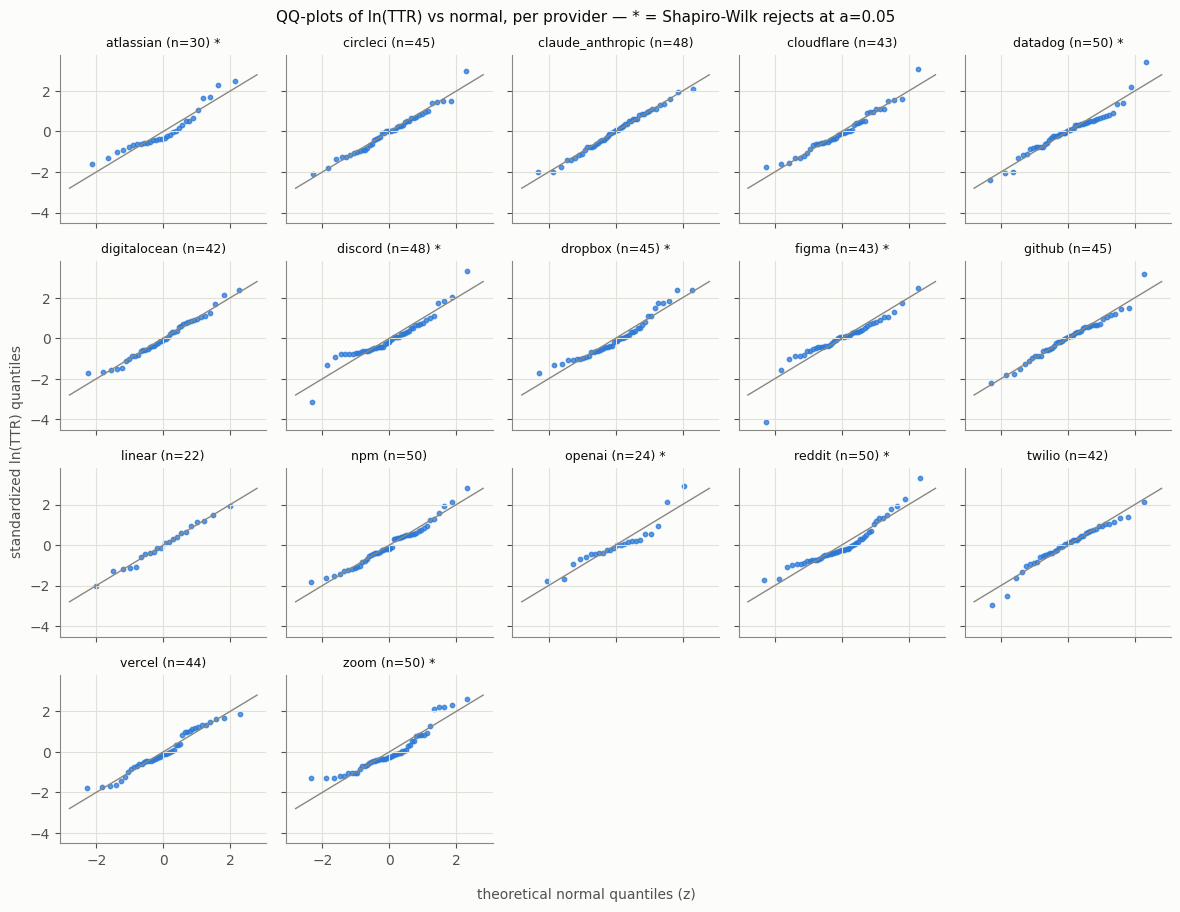

In [6]:
provs = sorted(fits_by_provider.keys())
ncols, nrows_ = 5, int(np.ceil(len(provs) / 5))
fig, axes = plt.subplots(nrows_, ncols, figsize=(12, 2.3 * nrows_), sharex=True, sharey=True)
for ax, prov in zip(axes.flat, provs):
    lx = np.sort(ttr.loc[ttr["provider"] == prov, "log_ttr"].to_numpy())
    z = stats.norm.ppf((np.arange(1, len(lx) + 1) - 0.5) / len(lx))
    zx = (lx - lx.mean()) / lx.std(ddof=1)
    ax.plot([-2.8, 2.8], [-2.8, 2.8], color=MUTED, lw=1)
    ax.scatter(z, zx, s=10, color=BLUE, alpha=0.75)
    rej = sw.loc[prov, "reject_lognormality_(a=0.05)"]
    ax.set_title(f"{prov} (n={len(lx)}){' *' if rej else ''}", fontsize=9)
for ax in axes.flat[len(provs):]:
    ax.axis("off")
fig.supxlabel("theoretical normal quantiles (z)", fontsize=10, color=INK2)
fig.supylabel("standardized ln(TTR) quantiles", fontsize=10, color=INK2)
fig.suptitle("QQ-plots of ln(TTR) vs normal, per provider — * = Shapiro-Wilk rejects at a=0.05",
             fontsize=11)
fig.tight_layout()
plt.show()

Shapiro-Wilk rejects log-normality for 8 of the 17 providers (zoom, figma, reddit, discord, atlassian, openai, dropbox and datadog, with p-values between 0.0003 and 0.033), while the other 9 look comfortably log-normal (claude_anthropic and linear near-perfectly so, p > 0.9). There is no contradiction with §4.4: AIC says log-normal is the best of the four candidates; Shapiro-Wilk says that for those eight it is still not the true distribution. The QQ-plots show where it breaks: the bodies track the normal line well, and the departures concentrate in the tails: clusters of suspiciously short durations (status-page bookkeeping: incidents opened and closed nearly simultaneously) and long-lived low-severity degradations that sit open for days.

So the working conclusion is a fairly narrow one: log-normal is an adequate working model of the body of TTR for every provider (fully adequate, in fact, for 9 of 17), but its extreme quantiles should not be trusted for the rejected ones. For promises (p95/p99 budgets), that means using empirical percentiles rather than model-extrapolated ones; the c²ₛ table in §4.7 quantifies the same disagreement from a different angle.

### 4.6 Outliers — GESD on centered ln(TTR), r = 5, read qualitatively

GESD (Rosner 1983) assumes approximate normality of the inlier body, which ln(TTR) plausibly satisfies. Run on provider-median-centered ln(TTR) with the pre-registered r = 5, α = 0.05. Whatever it flags gets read as *incidents with names*, not as points to delete.


In [7]:
def gesd(x, r, alpha=0.05):
    """Generalized ESD (Rosner 1983). Returns indices of x flagged as outliers."""
    x = np.asarray(x, dtype=float)
    idx = np.arange(len(x))
    flagged, stats_rows = [], []
    xx, ii = x.copy(), idx.copy()
    for i in range(1, r + 1):
        m, s = xx.mean(), xx.std(ddof=1)
        dev = np.abs(xx - m)
        j = dev.argmax()
        Ri = dev[j] / s
        n = len(xx)
        p = 1 - alpha / (2 * (n - i + 1))
        t = stats.t.ppf(p, n - i - 1)
        lam = (n - i) * t / np.sqrt((n - i - 1 + t**2) * (n - i + 1))
        stats_rows.append((i, Ri, lam, ii[j]))
        xx = np.delete(xx, j); ii = np.delete(ii, j)
    n_out = max([i for i, Ri, lam, _ in stats_rows if Ri > lam], default=0)
    flagged = [row[3] for row in stats_rows[:n_out]]
    table = pd.DataFrame(stats_rows, columns=["i", "R_i", "lambda_i", "row_idx"])
    return flagged, table

med_by_prov = ttr.groupby("provider")["log_ttr"].transform("median")
centered = (ttr["log_ttr"] - med_by_prov).to_numpy()
flag_pos, gesd_table = gesd(centered, r=5, alpha=0.05)
print(gesd_table.round(3).to_string(index=False))
print(f"\nGESD declares {len(flag_pos)} outlier(s) at r=5, a=0.05")

out_rows = ttr.iloc[flag_pos][["provider", "name", "impact", "created_at", "duration_min"]].copy()
out_rows["duration_days"] = (out_rows["duration_min"] / 1440).round(1)
out_rows.sort_values("duration_min", ascending=False)

 i   R_i  lambda_i  row_idx
 1 5.611     3.958      716
 2 3.936     3.957      385
 3 3.819     3.957      652
 4 3.758     3.956      310
 5 3.705     3.955      342

GESD declares 1 outlier(s) at r=5, a=0.05


,provider,name,impact,created_at,duration_min,duration_days
778,figma,Service disruption,minor,2023-12-10 04:18:25.632000+00:00,0.1,0.0


I ran the pre-registered outlier test expecting it to flag the multi-day monsters, and it flagged exactly one point out of 721 — on the short side. That single formal outlier is figma's "Service disruption" (impact minor, 2023-12-10), opened and resolved six seconds apart: a status-page bookkeeping artifact, an incident record created and immediately closed, not an operational event. It survives the duration > 0 filter but is data noise, not a finding about Figma.

The near-misses are more interesting than the outlier. Four incidents sit just below the flagging threshold (ranks 2–5, R ≈ 3.71–3.94 against λ ≈ 3.96; tested, not declared outliers): discord's "A/V E2EE Enforcement for Non-stage Voice Calls" (impact none, 8.9 days), zoom's "Service Degradation Affecting Giphy in Zoom Chat" (minor, 9.3 days), dropbox's "Some Windows users may not be able to use online-only functionality" (minor, 14.8 days), and one 2.8-minute twilio SMS blip. What the three long ones share is a pattern, not a coincidence: multi-day, low-severity degradations that a provider leaves open while a fix rolls out, not catastrophic outages.

The operational punchline is that under a log-normal model, even nine-to-fifteen-day incidents are not statistical outliers — they are the tail behaving exactly as the distribution says it should. You cannot clean your way to a comfortable TTR distribution by removing a few freak events. The heavy tail is the process, and capacity plans must carry it (§4.7).

### 4.7 c²ₛ per provider — the V input for NB03

The squared coefficient of variation of service time, c²ₛ = Var(S)/E[S]², is the variability factor that queueing corrections (Kingman / Allen-Cunneen, NB03) multiply into waiting time. M/M/c textbook math silently assumes c²ₛ = 1. Two estimates, as pre-registered: the log-normal-implied value **exp(σ̂²) − 1** (σ̂ from the MLE fit) and the **empirical CV²** computed directly from the data. If the log-normal fit is decent in the body but the empirical CV² is much larger, the tail is even heavier than log-normal, worth knowing before trusting either.


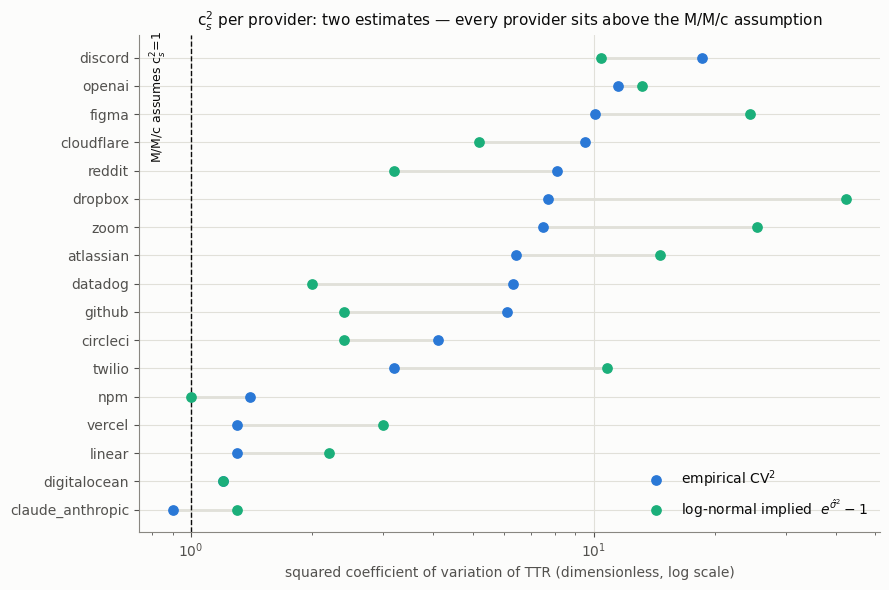

                   n  sigma_ln  c2s_lognormal  c2s_empirical
provider                                                    
claude_anthropic  48      0.91            1.3            0.9
digitalocean      42      0.89            1.2            1.2
linear            22      1.08            2.2            1.3
vercel            44      1.17            3.0            1.3
npm               50      0.84            1.0            1.4
twilio            42      1.57           10.8            3.2
circleci          45      1.11            2.4            4.1
github            45      1.11            2.4            6.1
datadog           50      1.04            2.0            6.3
atlassian         30      1.66           14.6            6.4
zoom              50      1.81           25.5            7.5
dropbox           45      1.94           42.4            7.7
reddit            50      1.20            3.2            8.1
cloudflare        43      1.35            5.2            9.5
figma             43    

In [8]:
c2s_rows = []
for prov in provs:
    x = ttr.loc[ttr["provider"] == prov, "duration_min"].to_numpy()
    s_hat = fits_by_provider[prov]["lognormal"]["params"][0]  # shape = sigma of ln
    c2s_rows.append({"provider": prov, "n": len(x),
                     "sigma_ln": round(s_hat, 2),
                     "c2s_lognormal": round(np.expm1(s_hat**2), 1),
                     "c2s_empirical": round(x.var(ddof=1) / x.mean()**2, 1)})
c2s = pd.DataFrame(c2s_rows).set_index("provider").sort_values("c2s_empirical")

fig, ax = plt.subplots(figsize=(9, 6))
ypos = np.arange(len(c2s))
ax.scatter(c2s["c2s_empirical"], ypos, color=BLUE, s=45, zorder=3, label="empirical CV$^2$")
ax.scatter(c2s["c2s_lognormal"], ypos, color=AQUA, s=45, zorder=3,
           label="log-normal implied  $e^{\\hat\\sigma^2}-1$")
for y, (_, row) in zip(ypos, c2s.iterrows()):
    ax.plot([min(row["c2s_empirical"], row["c2s_lognormal"]),
             max(row["c2s_empirical"], row["c2s_lognormal"])], [y, y],
            color=GRID, lw=2, zorder=1)
ax.axvline(1.0, color=INK, lw=1, ls="--")
ax.annotate("M/M/c assumes c$^2_s$=1", xy=(1.0, len(c2s) - 0.5), fontsize=9,
            color=INK, ha="right", rotation=90, xytext=(0.88, len(c2s) - 4.5))
ax.set_yticks(ypos, c2s.index)
ax.set_xscale("log")
ax.set_xlabel("squared coefficient of variation of TTR (dimensionless, log scale)")
ax.set_title("c$^2_s$ per provider: two estimates — every provider sits above the M/M/c assumption")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

print(c2s.to_string())
pooled_emp = ttr["duration_min"].var(ddof=1) / ttr["duration_min"].mean()**2
print(f"\nPooled empirical c2s (all providers, incl. cross-provider mixture variance): {pooled_emp:.1f}")

Empirical c²ₛ runs from 0.9 to 18.6 across providers, median around 6.3. The textbook M/M/c tables aren't wrong because someone computed them badly — they are exactly right for the world they assume, one where c²ₛ equals 1. This data lives in a different world, where resolution-time variability swings twenty-fold, from 0.9 at the calmest provider (claude_anthropic, the only one near the textbook's 1) to 18.6 at the noisiest, and that is precisely why tables built on the first world's assumption cannot answer this one's staffing question. The pooled value of 14.5 additionally mixes in cross-provider heterogeneity, so **the per-provider values, not the pooled one, are the right V input for NB03**, since the pooled number would double-count variance a router or triage layer already absorbs.

The two estimators (log-normal-implied and empirical CV²) disagree substantially for several providers, and in both directions: the log-normal-implied value overstates the empirical figure for zoom (25.5 vs 7.5), dropbox (42.4 vs 7.7), figma and atlassian (their σ̂ is inflated by the short-duration bookkeeping tail), and understates it for discord (10.4 vs 18.6), reddit (3.2 vs 8.1), and datadog (2.0 vs 6.3). The large disagreements line up, unsurprisingly, with the Shapiro-Wilk rejections in §4.5. The recommendation carried to NB03 is to use the empirical CV² (distribution-free) as the primary V input and the log-normal-implied value as a sensitivity bound, and where the two differ, the staffing answer should be reported as a range, not a point.

### 4.8 Severity strata — are `critical` incidents longer, or just more severe?

Pre-registered comparisons: critical vs minor, and major vs minor, on pooled duration, Mann-Whitney U plus a 10,000-resample bootstrap 95% CI on the *difference of medians*. Impact-convention caveat applies: labels are not calibrated across providers, so this is a coarse pooled read, not a per-provider severity model.


Strata sizes: {'critical': 32, 'major': 122, 'minor': 447, 'none': 120}



  comparison: critical vs minor
  n_critical: 32
  n_minor: 447
  median_critical: 84.6
  median_minor: 99.6
  U: 6479.0
  p_MW: 0.374
  median_diff: -15.0
  boot95_CI: (np.float64(-40.2), np.float64(25.2))
  CI_width_min: 65.4

  comparison: major vs minor
  n_major: 122
  n_minor: 447
  median_major: 73.6
  median_minor: 99.6
  U: 22771.0
  p_MW: 0.0052
  median_diff: -26.0
  boot95_CI: (np.float64(-46.8), np.float64(-5.4))
  CI_width_min: 41.4


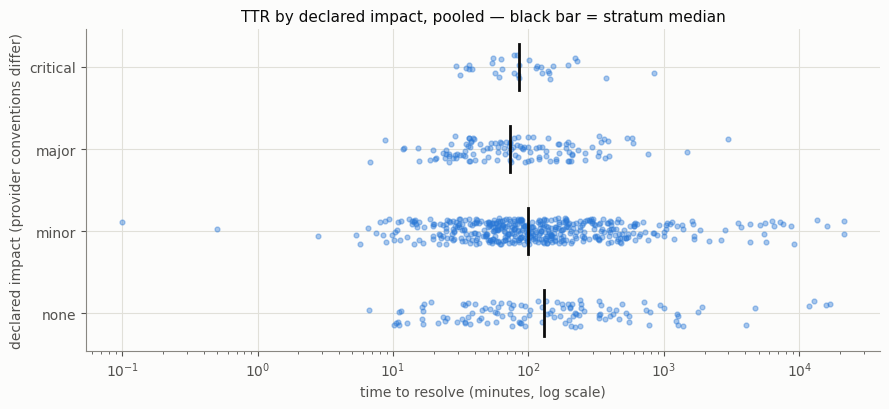

In [9]:
def mw_and_boot(a, b, label_a, label_b, rng, n_boot=10_000):
    U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = (np.median(rng.choice(a, len(a), replace=True))
                    - np.median(rng.choice(b, len(b), replace=True)))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return {"comparison": f"{label_a} vs {label_b}",
            f"n_{label_a}": len(a), f"n_{label_b}": len(b),
            f"median_{label_a}": round(np.median(a), 1),
            f"median_{label_b}": round(np.median(b), 1),
            "U": round(U, 0), "p_MW": round(p, 4),
            "median_diff": round(np.median(a) - np.median(b), 1),
            "boot95_CI": (round(lo, 1), round(hi, 1)),
            "CI_width_min": round(hi - lo, 1)}

by_imp = {k: g["duration_min"].to_numpy() for k, g in ttr.groupby("impact")}
print("Strata sizes:", {k: len(v) for k, v in by_imp.items()})

res_crit = mw_and_boot(by_imp["critical"], by_imp["minor"], "critical", "minor", rng)
res_maj  = mw_and_boot(by_imp["major"],    by_imp["minor"], "major",    "minor", rng)
for r in (res_crit, res_maj):
    print()
    for k, v in r.items():
        print(f"  {k}: {v}")

order = ["none", "minor", "major", "critical"]
fig, ax = plt.subplots(figsize=(9, 4.2))
for i, imp in enumerate(order):
    v = by_imp.get(imp, np.array([]))
    jitter = rng.uniform(-0.16, 0.16, len(v))
    ax.scatter(v, i + jitter, s=12, color=BLUE, alpha=0.4, zorder=2)
    ax.plot([np.median(v)] * 2, [i - 0.28, i + 0.28], color=INK, lw=2, zorder=3)
ax.set_xscale("log")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("time to resolve (minutes, log scale)")
ax.set_ylabel("declared impact (provider conventions differ)")
ax.set_title("TTR by declared impact, pooled — black bar = stratum median")
fig.tight_layout()
plt.show()

The strata comparison comes out inverted from the naive expectation: higher declared severity does not mean longer incidents — if anything, the opposite. Majors resolve faster than minors at the median, 73.6 versus 99.6 minutes, a 26-minute gap that survives a Mann-Whitney test (p = 0.005) with a bootstrap 95% CI of −46.8 to −5.4 minutes. Criticals show no detectable difference from minors (84.6 versus 99.6 minutes, p = 0.37, CI −40.2 to +25.2 minutes), though with only 32 criticals that CI is honestly wide enough that a moderate effect in either direction is still compatible with the data.

Two explanations fit equally well, and they are not mutually exclusive. One is real triage behavior: severe incidents get all-hands urgency, fast mitigation, and fast status-page closure, while low-severity degradations are allowed to linger for days (exactly the pattern GESD's near-misses surfaced in §4.6). The other is the declared-impact convention problem: providers that label liberally (major at Discord) or stingily (none at Figma/Atlassian) contaminate the pooled strata. Either way, the operational conclusion holds: declared severity is not a duration predictor, a theme NB04 picks up formally, though one of these two results is Twilio-fragile, as §4.9 shows next.

### 4.9 Twilio sensitivity — do the headlines survive removing one 8-day platform crisis?

Twilio contributes 42 analyzable incidents captured in an ~8-day window with an unusually high median, plausibly one correlated crisis, not independent draws. As pre-registered, every headline number is recomputed without Twilio.


In [10]:
def headline(d, rng, label):
    x = d["duration_min"]
    out = {"set": label, "n": len(d),
           "pooled_median": round(x.median(), 1),
           "pooled_mean": round(x.mean(), 1),
           "mean/median": round(x.mean() / x.median(), 2),
           "pooled_p95": round(x.quantile(0.95), 1),
           "pooled_c2s_emp": round(x.var(ddof=1) / x.mean()**2, 1)}
    # contest winner counts across providers (>=20)
    winners = {}
    ln_tie = 0; nprov = 0
    for prov, g in d.groupby("provider"):
        v = g["duration_min"].to_numpy()
        if len(v) < 20:
            continue
        nprov += 1
        res = fit_contest(v)
        aics = {k: r["aic"] for k, r in res.items()}
        best = min(aics, key=aics.get)
        winners[best] = winners.get(best, 0) + 1
        if aics["lognormal"] - aics[best] < 2:
            ln_tie += 1
    out["contest_winners"] = winners
    out["lognormal_in_dAIC<2_set"] = f"{ln_tie}/{nprov}"
    # severity tests
    bi = {k: g["duration_min"].to_numpy() for k, g in d.groupby("impact")}
    rc = mw_and_boot(bi["critical"], bi["minor"], "critical", "minor", rng)
    rm = mw_and_boot(bi["major"], bi["minor"], "major", "minor", rng)
    out["crit_vs_minor: p, median_diff, CI"] = (rc["p_MW"], rc["median_diff"], rc["boot95_CI"])
    out["major_vs_minor: p, median_diff, CI"] = (rm["p_MW"], rm["median_diff"], rm["boot95_CI"])
    return out

rng = np.random.default_rng(20240401)  # reset for reproducibility of this cell
with_t = headline(ttr, rng, "with twilio")
rng = np.random.default_rng(20240401)
without_t = headline(ttr[ttr["provider"] != "twilio"], rng, "without twilio")
sens = pd.DataFrame([with_t, without_t]).set_index("set").T
sens

set,with twilio,without twilio
n,721,679
pooled_median,94.8,89.2
pooled_mean,505.3,485.8
mean/median,5.33,5.45
pooled_p95,1391.4,1257.4
pooled_c2s_emp,14.5,16.1
contest_winners,"{'lognormal': 16, 'weibull': 1}",{'lognormal': 16}
lognormal_in_dAIC<2_set,17/17,16/16
"crit_vs_minor: p, median_diff, CI","(0.374, -15.0, (-40.2, 25.2))","(0.7127, -5.9, (-30.3, 32.1))"
"major_vs_minor: p, median_diff, CI","(0.0052, -26.0, (-46.8, -5.4))","(0.0455, -16.9, (-35.3, 2.7))"


The distributional headlines are robust to dropping Twilio; one severity conclusion is not. Robust, with Twilio present versus removed: pooled median moves 94.8 to 89.2 minutes, pooled mean 505 to 486, the mean/median ratio 5.3 to 5.5, pooled p95 1391 to 1257, and pooled empirical c²ₛ 14.5 to 16.1, and it rises because Twilio's TTRs are high but comparatively tight, so removing them makes the remaining mix more variable, not less. The distribution contest becomes unanimous: 16 of 16 log-normal raw wins once Twilio's lone Weibull win disappears with it, log-normal inside the ΔAIC < 2 set for all 16. The critical-versus-minor null stays null (p moves from 0.37 to 0.71).

What does not survive is the major-faster-than-minor result. Its p-value moves from 0.0052 to 0.0455, and the 95% CI shifts from (−46.8, −5.4) to (−35.3, +2.7) — it now crosses zero. A single provider's 8-day crisis week, which contributed many fast-closed minor-adjacent incidents, carries a real share of that finding. I don't trust this one, and I'd rather say so plainly than dress it up: "major incidents resolve somewhat faster than minor ones" is suggestive, not established, and it stays in this notebook only because I pre-registered the test, not because I'd bet on it holding next quarter.

## 5. The answer, and how much to trust it

When a status page says "incidents resolve in about an hour," it is speaking median, and the median is the wrong number for almost every budgeting decision built on top of it.

The gap behind that sentence is large and universal: pooled, the median is 95 minutes and the mean is 505 (a 5.3× ratio), with p90 at 601 minutes (~10 h), p95 at 1391 minutes (~23 h), and p99 near 11,200 minutes (~7.8 days). All 17 providers have mean above median, with the per-provider ratio ranging 1.4×–12.8× and a median of 2.2×, and none of these headline numbers moves materially once Twilio is removed (§4.9).

The shape is approximately log-normal, as the multiplicative-process theory in §4.2 predicts: the raw AIC winner for 16 of 17 providers, the sole winner for 14, and inside the ΔAIC < 2 set for all 17 — the single Weibull win belongs to Twilio, both a statistical tie and the least trustworthy sample in the data. But Shapiro-Wilk rejects strict log-normality for 8 of 17, with the damage concentrated in the tails, which is why the model earns its keep for the body while promises should run on empirical percentiles instead.

Variability sits far above what textbook queueing math assumes: empirical c²ₛ per provider runs 0.9–18.6, median around 6.3, against the c²ₛ = 1 that M/M/c staffing tables quietly assume. That gap is the V input NB03 needs, and it makes the Kingman/Allen-Cunneen correction there non-optional rather than a nice-to-have. Where the log-normal-implied and empirical estimates disagree (mostly the Shapiro-rejected providers), NB03 should carry both as a sensitivity band rather than pick one.

The tail is structural, not an accumulation of outliers: the pre-registered GESD test (r = 5) flags exactly one point in 721, a six-second bookkeeping artifact on the short side. Multi-day incidents are not anomalies waiting to be deleted. They are the distribution.

Declared severity, finally, does not predict duration. Critical versus minor shows no detectable median difference (95% CI −40 to +25 min). Major versus minor shows majors resolving about 26 minutes faster at the median (CI −47 to −5), but drop Twilio and that CI crosses zero. I report it because I pre-registered it, not because I'd stake much on it holding next quarter.

Put plainly: communicate with the median (~1.5 h), staff with the mean (~8.4 h pooled) plus c²ₛ, and promise or escalate with an empirical high percentile (pooled p90 ≈ 10 h; per-provider values in §4.3).

## 6. What I would do differently

The first habit this data should change is small and almost embarrassing: every time a status page or a dashboard reports a "typical resolution time," it is worth asking which statistic is hiding inside the word *typical*. In this data the mean runs about five times the median — not a rounding error but a 5× budgeting mistake committed before anyone opens a spreadsheet.

From there the division of labor falls out on its own, and each number earns a different job. The median (~1.5 hours pooled) belongs to conversations with humans (runbooks, user communications, "what usually happens"). The mean (~8.4 hours pooled), together with its variability, belongs to staffing: offered load consumes the mean, waiting time scales with (1 + c²ₛ)/2, and with c²ₛ sitting between roughly 4 and 19 for most providers, a headcount pulled straight from M/M/c tables will be wrong by an amount you can see from across the room (NB03 quantifies exactly how much, using this notebook's per-provider means and empirical c²ₛ as inputs). Promises and escalation clocks (SLOs, "when do we call this a crisis?") belong to empirical percentiles (p90 ≈ 10 hours pooled), not to the fitted tail, because the log-normal model stops being trustworthy for about half these providers exactly where promises live. One pleasant consequence follows from TTR being far from memoryless: "this incident has already run three hours" is genuine evidence that it is a long one, so an escalation clock triggered by elapsed time is not corporate paranoia — it is statistics doing its job.

Two temptations are worth resisting on purpose. The first is gating escalation on declared severity: severity does not predict duration here (if anything, majors close a little faster), so a severity-triggered clock is really a clock triggered by each provider's house vocabulary for labeling incidents. Whether any minute-zero signal predicts duration is NB04's question to answer, not this notebook's. The second temptation is cleaning the data. Anyone tempted to "exclude the weird incidents" should look first at what the pre-registered outlier test actually flagged: one point in 721, a six-second bookkeeping artifact, on the short side. The multi-day incidents are not noise sitting on top of the real process — they are the process, and they are the entire reason a staffing plan needs to exist in the first place.

One last thing, about Twilio specifically. Its entire sample is a single eight-day crisis, and one conclusion in this notebook (the major-vs-minor inversion) does not survive dropping it. Whether next quarter's incidents will look anything like this eight-day window is a question this notebook cannot answer, which happens to be exactly the question any staffing plan is implicitly betting on. That question belongs to another notebook, but the cheapest way to start answering it would be to re-run this capture monthly and watch whether the per-provider medians hold, since it attacks the window problem directly, and every other conclusion in this stack inherits whatever stability that check turns up.

## 7. Where I would not follow this data

- Whether your incidents look like this. These are provider-declared status-page incidents; your internal ticket TTR is a different process with different detection and closure conventions. The method (fit, test, budget with mean plus c²ₛ, and a percentile) transfers; the numbers don't automatically.
- Pure repair time. Status pages timestamp declare→"resolved": detection lag, mitigation, verification, and communication are all folded together. Kline's log-normal prior is about repair specifically; the contest here judged a broader process, so agreement or disagreement with that prior says nothing definitive about wrench-time distributions on their own.
- True incident rates or cross-provider reliability rankings. Observation windows differ by roughly 250× across providers, and providers self-select which incidents they declare in the first place: that's left-censorship built into the status page. Nothing here supports a claim like "provider X is more reliable than provider Y."
- Severity in any calibrated sense. Impact labels follow each provider's house style (Figma labels almost everything none, Discord reaches for major easily), so the strata comparison is a pooled, convention-contaminated read, not a calibrated severity model.
- Stationarity. Twilio's window is one bad week; Atlassian's spans years of process changes. A distribution fit assumes draws from one stable process, which is visibly false for some providers here, precisely why the Twilio sensitivity analysis exists and why the per-provider σ estimates carry no warranty across time windows.
- Forecasts. A good distributional fit over an observation window is not a claim that next quarter's TTRs will be exchangeable with this window's.